In [41]:
import os
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms
from torchvision import models

import cv2
import matplotlib.pyplot as plt

In [7]:
!pip install opencv-python

In [1]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [42]:
import sys

print(sys.executable)

D:\Anacondaaa\python.exe


In [43]:
os.listdir (r"D:\data\dataset")

['cars', 'cats']

In [44]:
root = (r"D:\data\dataset")

In [45]:
import pandas as pd

In [46]:
data_dict = {'X': [], 'y': []}

class_map = {
    'cars': 0,
    'cats': 1
}

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)

    for img in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img)

        data_dict['X'].append(img_path)
        data_dict['y'].append(class_map[cls])

df = pd.DataFrame(data_dict)

df

,X,y
0,D:\data\dataset\cars\car1.jpg,0
1,D:\data\dataset\cars\car2.jpg,0
2,D:\data\dataset\cars\car3.jpg,0
3,D:\data\dataset\cars\car4.jpg,0
4,D:\data\dataset\cars\car5.jpg,0
5,D:\data\dataset\cats\cat1.jpg,1
6,D:\data\dataset\cats\cat2.jpg,1
7,D:\data\dataset\cats\cat3.jpg,1
8,D:\data\dataset\cats\cat4.jpg,1
9,D:\data\dataset\cats\cat5.jpg,1


In [47]:
pd.DataFrame(data_dict)

,X,y
0,D:\data\dataset\cars\car1.jpg,0
1,D:\data\dataset\cars\car2.jpg,0
2,D:\data\dataset\cars\car3.jpg,0
3,D:\data\dataset\cars\car4.jpg,0
4,D:\data\dataset\cars\car5.jpg,0
5,D:\data\dataset\cats\cat1.jpg,1
6,D:\data\dataset\cats\cat2.jpg,1
7,D:\data\dataset\cats\cat3.jpg,1
8,D:\data\dataset\cats\cat4.jpg,1
9,D:\data\dataset\cats\cat5.jpg,1


In [48]:
class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        x = cv2.imread(self.data_dict['X'][idx])
        y = self.data_dict['y'][idx]
        if self.transforms:
            x = self.transforms(x)
            y = torch.tensor(y)
        return x, y

    def __len__(self):
        return len(self.data_dict['X'])

In [49]:

trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size=(300, 300)),
    transforms.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
])

cd = CustomDataset(data_dict, trans)

In [50]:

for i in cd:
    print(i[0].shape)

torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])
torch.Size([3, 300, 300])


In [52]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

In [53]:

x = cd[4][0].unsqueeze(dim=0)

In [54]:
y_pred = model(x)

In [55]:
torch.argmax(y_pred)

tensor(479)

In [56]:
classes = models.ResNet50_Weights.DEFAULT.meta

In [57]:
classes.keys()

dict_keys(['min_size', 'categories', 'num_params', 'recipe', '_metrics', '_ops', '_file_size', '_docs'])

In [58]:
classes['categories'][185]

'Norfolk terrier'

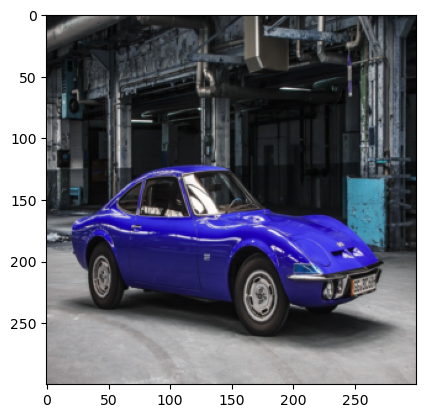

In [59]:
plt.imshow(cd[4][0].permute(1,2,0))

In [60]:
torch.argmax(F.softmax(y_pred))

C:\Users\Admin\AppData\Local\Temp\ipykernel_8504\153894831.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  torch.argmax(F.softmax(y_pred))


tensor(479)

In [61]:
F.softmax(y_pred)[0]

C:\Users\Admin\AppData\Local\Temp\ipykernel_8504\3111965656.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(y_pred)[0]


tensor([0.0011, 0.0011, 0.0008, 0.0007, 0.0009, 0.0009, 0.0009, 0.0008, 0.0011,
        0.0009, 0.0009, 0.0008, 0.0010, 0.0010, 0.0009, 0.0008, 0.0009, 0.0010,
        0.0008, 0.0008, 0.0013, 0.0008, 0.0008, 0.0008, 0.0009, 0.0008, 0.0009,
        0.0010, 0.0009, 0.0010, 0.0010, 0.0009, 0.0010, 0.0008, 0.0009, 0.0009,
        0.0012, 0.0010, 0.0010, 0.0011, 0.0010, 0.0011, 0.0010, 0.0009, 0.0010,
        0.0010, 0.0012, 0.0011, 0.0009, 0.0012, 0.0011, 0.0011, 0.0010, 0.0011,
        0.0010, 0.0009, 0.0009, 0.0008, 0.0012, 0.0010, 0.0009, 0.0011, 0.0009,
        0.0009, 0.0010, 0.0008, 0.0010, 0.0009, 0.0008, 0.0010, 0.0010, 0.0009,
        0.0009, 0.0010, 0.0010, 0.0012, 0.0010, 0.0012, 0.0014, 0.0010, 0.0010,
        0.0009, 0.0012, 0.0010, 0.0009, 0.0011, 0.0012, 0.0011, 0.0011, 0.0011,
        0.0010, 0.0009, 0.0008, 0.0008, 0.0011, 0.0009, 0.0009, 0.0008, 0.0007,
        0.0008, 0.0009, 0.0008, 0.0009, 0.0011, 0.0011, 0.0012, 0.0011, 0.0008,
        0.0008, 0.0007, 0.0007, 0.0010, 